In [ ]:

def plot_autoencoder_stats(
        x: Tensor = None,
        x_hat: Tensor = None,
        z: Tensor = None,
        y: Tensor = None,
        epoch: int = None,
        train_loss: List = None,
        valid_loss: List = None,
        classes: List = None,
        dimensionality_reduction_op: Optional[Callable] = None,
) -> None:
    """import os
from typing import *

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from IPython.display import Image, display, clear_output
from sklearn.manifold import TSNE
from torch import Tensor
from torch.distributions import Normal
from torchvision.utils import make_grid


    An utility 
    """
    # -- Plotting --
    f, axarr = plt.subplots(2, 2, figsize=(20, 20))

    # Loss
    ax = axarr[0, 0]
    ax.set_title("Error")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Error')

    ax.plot(np.arange(epoch + 1), train_loss, color="black")
    ax.plot(np.arange(epoch + 1), valid_loss, color="gray", linestyle="--")
    ax.legend(['Training error', 'Validation error'])

    # Latent space
    ax = axarr[0, 1]

    ax.set_title('Latent space')
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')

    # If you want to use a dimensionality reduction method you can use
    # for example TSNE by projecting on two principal dimensions
    # TSNE.fit_transform(z)
    if dimensionality_reduction_op is not None:
        z = dimensionality_reduction_op(z)

    colors = iter(plt.get_cmap('Set1')(np.linspace(0, 1.0, len(classes))))
    for c in classes:
        ax.scatter(*z[y.numpy() == c].T, c=next(colors), marker='o')

    ax.legend(classes)

    # Inputs
    ax = axarr[1, 0]
    ax.set_title('Inputs')
    ax.axis('off')

    rows = 8
    batch_size = x.size(0)
    columns = batch_size // rows

    canvas = np.zeros((28 * rows, columns * 28))
    for i in range(rows):
        for j in range(columns):
            idx = i % columns + rows * j
            canvas[i * 28:(i + 1) * 28, j * 28:(j + 1) * 28] = x[idx].reshape((28, 28))
    ax.imshow(canvas, cmap='gray')

    # Reconstructions
    ax = axarr[1, 1]
    ax.set_title('Reconstructions')
    ax.axis('off')

    canvas = np.zeros((28 * rows, columns * 28))
    for i in range(rows):
        for j in range(columns):
            idx = i % columns + rows * j
            canvas[i * 28:(i + 1) * 28, j * 28:(j + 1) * 28] = x_hat[idx].reshape((28, 28))

    ax.imshow(canvas, cmap='gray')

    tmp_img = "tmp_ae_out.png"
    plt.savefig(tmp_img)
    plt.close(f)
    display(Image(filename=tmp_img))
    clear_output(wait=True)

    os.remove(tmp_img)


def plot_samples(ax, x):
    x = x.to('cpu')
    nrow = int(np.sqrt(x.size(0)))
    x_grid = make_grid(x.view(-1, 1, 28, 28), nrow=nrow).permute(1, 2, 0)
    ax.imshow(x_grid)
    ax.axis('off')


def plot_interpolations(ax, vae):
    device = next(iter(vae.parameters())).device
    nrow = 10
    nsteps = 10
    prior_params = vae.prior_params.expand(2 * nrow, *vae.prior_params.shape[-1:])
    mu, log_sigma = prior_params.chunk(2, dim=-1)
    pz = Normal(mu, log_sigma.exp())
    z = pz.sample().view(nrow, 2, -1)
    t = torch.linspace(0, 1, 10, device=device)
    zs = t[None, :, None] * z[:, 0, None, :] + (1 - t[None, :, None]) * z[:, 1, None, :]
    px = vae.observation_model(zs.view(nrow * nsteps, -1))
    x = px.sample()
    x = x.to('cpu')
    x_grid = make_grid(x.view(-1, 1, 28, 28), nrow=nrow).permute(1, 2, 0)
    ax.imshow(x_grid)
    ax.axis('off')


def plot_grid(ax, vae):
    device = next(iter(vae.parameters())).device
    nrow = 10
    xv, yv = torch.meshgrid([torch.linspace(-3, 3, 10), torch.linspace(-3, 3, 10)])
    zs = torch.cat([xv[:, :, None], yv[:, :, None]], -1)
    zs = zs.to(device)
    px = vae.observation_model(zs.view(nrow * nrow, 2))
    x = px.sample()
    x = x.to('cpu')
    x_grid = make_grid(x.view(-1, 1, 28, 28), nrow=nrow).permute(1, 2, 0)
    ax.imshow(x_grid)
    ax.axis('off')


def plot_2d_latents(ax, qz, z, y):
    z = z.to('cpu')
    y = y.to('cpu')
    scale_factor = 2
    batch_size = z.shape[0]
    palette = sns.color_palette()
    colors = [palette[l] for l in y]

    # plot prior
    prior = plt.Circle((0, 0), scale_factor, color='gray', fill=True, alpha=0.1)
    ax.add_artist(prior)

    # plot data points
    mus, sigmas = qz.mu.to('cpu'), qz.sigma.to('cpu')
    mus = [mus[i].numpy().tolist() for i in range(batch_size)]
    sigmas = [sigmas[i].numpy().tolist() for i in range(batch_size)]

    posteriors = [
        plt.matplotlib.patches.Ellipse(mus[i], *(scale_factor * s for s in sigmas[i]), color=colors[i], fill=False,
                                       alpha=0.3) for i in range(batch_size)]
    for p in posteriors:
        ax.add_artist(p)

    ax.scatter(z[:, 0], z[:, 1], color=colors)

    ax.set_xlim([-3, 3])
    ax.set_ylim([-3, 3])
    ax.set_aspect('equal', 'box')


def plot_latents(ax, z, y):
    z = z.to('cpu')
    palette = sns.color_palette()
    colors = [palette[l] for l in y]
    z = TSNE(n_components=2).fit_transform(z)
    ax.scatter(z[:, 0], z[:, 1], color=colors)


def make_vae_plots(vae, x, y, outputs, training_data, validation_data, tmp_img="tmp_vae_out.png", figsize=(18, 18)):
    fig, axes = plt.subplots(3, 3, figsize=figsize, squeeze=False)

    # plot the observation
    axes[0, 0].set_title(r'Observation $\mathbf{x}$')
    plot_samples(axes[0, 0], x)

    # plot the latent samples
    try:
        z = outputs['z']
        if z.shape[1] == 2:
            axes[0, 1].set_title(r'Latent Samples $\mathbf{z} \sim q_\phi(\mathbf{z} | \mathbf{x})$')
            qz = outputs['qz']
            plot_2d_latents(axes[0, 1], qz, z, y)
        else:
            axes[0, 1].set_title(r'Latent Samples $\mathbf{z} \sim q_\phi(\mathbf{z} | \mathbf{x})$ (t-SNE)')
            plot_latents(axes[0, 1], z, y)
    except Exception as e:
        print(f"Could not generate the plot of the latent sanples because of exception")
        print(e)

    # plot posterior samples
    axes[0, 2].set_title(
        r'Reconstruction $\mathbf{x} \sim p_\theta(\mathbf{x} | \mathbf{z}), \mathbf{z} \sim q_\phi(\mathbf{z} | \mathbf{x})$')
    px = outputs['px']
    x_sample = px.sample().to('cpu')
    plot_samples(axes[0, 2], x_sample)

    # plot ELBO
    ax = axes[1, 0]
    ax.set_title(r'ELBO: $\mathcal{L} ( \mathbf{x} )$')
    ax.plot(training_data['elbo'], label='Training')
    ax.plot(validation_data['elbo'], label='Validation')
    ax.legend()

    # plot KL
    ax = axes[1, 1]
    ax.set_title(r'$\mathcal{D}_{\operatorname{KL}}\left(q_\phi(\mathbf{z}|\mathbf{x})\ |\ p(\mathbf{z})\right)$')
    ax.plot(training_data['kl'], label='Training')
    ax.plot(validation_data['kl'], label='Validation')
    ax.legend()

    # plot NLL
    ax = axes[1, 2]
    ax.set_title(r'$\log p_\theta(\mathbf{x} | \mathbf{z})$')
    ax.plot(training_data['log_px'], label='Training')
    ax.plot(validation_data['log_px'], label='Validation')
    ax.legend()

    # plot prior samples
    axes[2, 0].set_title(r'Samples $\mathbf{x} \sim p_\theta(\mathbf{x} | \mathbf{z}), \mathbf{z} \sim p(\mathbf{z})$')
    px = vae.sample_from_prior(batch_size=x.size(0))['px']
    x_samples = px.sample()
    plot_samples(axes[2, 0], x_samples)

    # plot interpolations samples
    axes[2, 1].set_title(
        r'Latent Interpolations: $\mathbf{x} \sim p_\theta(\mathbf{x} | t \cdot \mathbf{z}_1 + (1-t) \cdot \mathbf{z}_2), \mathbf{z}_1, \mathbf{z}_2 \sim p(\mathbf{z}), t=0 \dots 1$')
    plot_interpolations(axes[2, 1], vae)

    # plot samples (sampling from a grid instead of the prior)
    if vae.latent_features == 2:
        axes[2, 2].set_title(
            r'Samples: $\mathbf{x} \sim p_\theta(\mathbf{x} | \mathbf{z}), \mathbf{z} \sim \operatorname{grid}(-3:3, -3:3)$')
        px = vae.sample_from_prior(batch_size=x.size(0))['px']
        x_samples = px.sample()
        plot_grid(axes[2, 2], vae)

    # display
    plt.tight_layout()
    plt.savefig(tmp_img)
    plt.close(fig)
    display(Image(filename=tmp_img))
    clear_output(wait=True)

    os.remove(tmp_img)

In [59]:
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Image, display, clear_output
import numpy as np
%matplotlib nbagg
%matplotlib inline
import seaborn as sns
sns.set_style("whitegrid")
sns.set_palette(sns.dark_palette("purple"))

try:
    from plotting import plot_autoencoder_stats
except Exception as ex:
    print(f"If using Colab, you may need to upload `plotting.py`. \
          \nIn the left pannel, click `Files > upload to session storage` and select the file `plotting.py` from your computer \
          \n---------------------------------------------")
    print(ex)

If using Colab, you may need to upload `plotting.py`.           
In the left pannel, click `Files > upload to session storage` and select the file `plotting.py` from your computer           
---------------------------------------------
cannot import name 'plot_autoencoder_stats' from 'plotting' (/Users/holgermaxfloelyng/Desktop/BioMed/MSc_Biomed/SEM_2/02456_Deep_learning/Week1_8/Lecture_7/plotting.py)


# Unsupservised Learning 

## Labelling Data is Expensive

In supervised machine learning, one aims at learning a mapping $f_{\psi} : \mathbf{x} \in \mathcal{R}^P \rightarrow \mathbf{y}$ from observations $\mathbf{x}$ to the target $\mathbf{y}$ using a dataset $\mathcal{D} = \{\mathbf{x}_i, \mathbf{y}_i\}_{i=1, \dots, N}$ of finite size N (e.g. image classification, translation). Because of the curse of dimensionality, high-dimensional inputs (images) and complex the models (deep learning) require large datasets (million of pairs $(\mathbf{x}, \mathbf{y})$). In practice, labelling data is expensive (e.g. marking the presence of cancer in X-ray chest scans). 

## Compression is Comprehension: Learning without Target

In order to overcome the curse of dimensionality, we aim at learning a compressed representation $\mathbf{z} \in \mathcal{R}^M$ of $\mathbf{x}$ such that $M < P$ and there is a mapping $g_{\phi}: \mathbf{x} \rightarrow \mathbf{z}$ linking each data point to its representation. Ideally, $\mathbf{z}$ is low-dimensional set of features which efficiently describes $\mathbf{x}$. As an illustration, when modelling pictures of celebrities (CelebA dataset), the set of facial features (eye color, age, hair lenth, etc.) is a compressed (and lossy) representation of $\mathbf{x}$. In practice, the representation  $\mathbf{z}$ is unobservable and [unlikely to overlap with such known features](https://arxiv.org/abs/1811.12359). Yet, the representation $\mathbf{z}$ is low dimensional and learning a mapping $f_{\psi} : \mathbf{z} \in \mathcal{R}^M \rightarrow \mathbf{y}$ is often easier.

Whereas labelling the data is expensive, observations $\mathbf{x}$ are cheap to acquire. In many cases, one can scrap the web to gather a large collection of images or text. As a result, large deep learning models can be deployed to learn $g_{\phi}$, and smaller / data-efficient models can be applied downstream to solve the supervised task.



# Auto-encoders: Compression as a Generation Process
In this notebook you will implement a simple auto-encoder (AE). We assume that you are already familiar with the basics of neural networks. We will start by defining an AE similar to the one used for the finetuning step by [Geoffrey Hinton and Ruslan Salakhutdinov](https://www.cs.toronto.edu/~hinton/science.pdf). We will experiment with the AE setup and try to run it on the MNIST dataset. There has been a wide variety of research into the field of auto-encoders and the technique that you are about to learn is very simple compared to modern methods: Masked Autoencoders ([MADE](https://arxiv.org/abs/1502.03509), [BERT](https://arxiv.org/abs/1810.04805)) and Variational Autoencoders ([VAE](https://arxiv.org/abs/1312.6114), [VQ-VAE](https://arxiv.org/abs/1711.00937), [BIVA](https://arxiv.org/abs/1902.02102), [NVAE](https://arxiv.org/abs/2007.03898)).

In unsupervised learning, we aim at learning compressed representations $\mathbf{z} \in \mathcal{M}$ of $\mathbf{x} \in \mathcal{P}$ where $ M < P$. The architecture of an autoencoder can be decomposed in two steps:

1. *Encoding* $\mathbf{x}$ into a low-dimensional representation $\mathbf{z}$ using a neural network $g_{\phi} : \mathbf{x} \rightarrow \mathbf{z}$.
2. *Decoding* the representation $\mathbf{z}$ into a reconstruction $\hat{\mathbf{x}} = h_\theta(\mathbf{z}) \in \mathcal{R}^P$.

Because $M < P$, the encoding acts as an information bottleneck: only part of the information describing $\mathbf{x}$ can be encoded into $\mathbf{z}$ as long as $M$ is sufficiently small.

Learning the parameters of the autoencoder relies on two aspects:

1. A distance in the observation space $d : \mathcal{R}^{P} \times \mathcal{R}^{P} \rightarrow \mathcal{R}$ (e.g. MSE), measuring the reconstruction quality.
2. Using backpropagation coupled with stochastic gradient descent (SGD) to optimize the parameters $\{\phi, \theta\}$ w.r.t $L := \frac{1}{N} \sum_i d(x_i, h_{\theta}(g_{\phi}(\mathbf{x})))$.

<img src="static/autoencoder.png" />

*The exercises are found at the bottom of the notebook*

## MNIST
First let us load the MNIST dataset and plot a few examples. In this notebook we will use the *dataloaders* and *datasets* provided by PyTorch. Defining the loading of datasets using a dataloader has the advantage that it only load the data that is *neccessary* into memory, which enables us to use very large scale datasets.

We only load a limited amount of classes defined by the `classes` variable to speed up training.

In [119]:
import torch
cuda = torch.cuda.is_available()
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torchvision import transforms

# Flatten the 2d-array image into a vector
#flatten = lambda x: ToTensor()(x).view(28**2) # for linear ffn
transform_cnn = transforms.ToTensor()

# Define the train and test sets
dset_train = MNIST("./", train=True,  transform=transform_cnn, download=True)
dset_test  = MNIST("./", train=False, transform=transform_cnn)

# The digit classes to use
classes = [1, 2, 3, 7, 9]

def stratified_sampler(labels, classes):
    """Sampler that only picks datapoints corresponding to the specified classes"""
    from functools import reduce
    (indices,) = np.where(reduce(lambda x, y: x | y, [labels.numpy() == i for i in classes]))
    indices = torch.from_numpy(indices)
    return SubsetRandomSampler(indices)


# The loaders perform the actual work
batch_size = 64
train_loader = DataLoader(dset_train, batch_size=batch_size,
                          sampler=stratified_sampler(dset_train.targets, classes), pin_memory=cuda)
test_loader  = DataLoader(dset_test, batch_size=batch_size, 
                          sampler=stratified_sampler(dset_test.targets, classes), pin_memory=cuda)

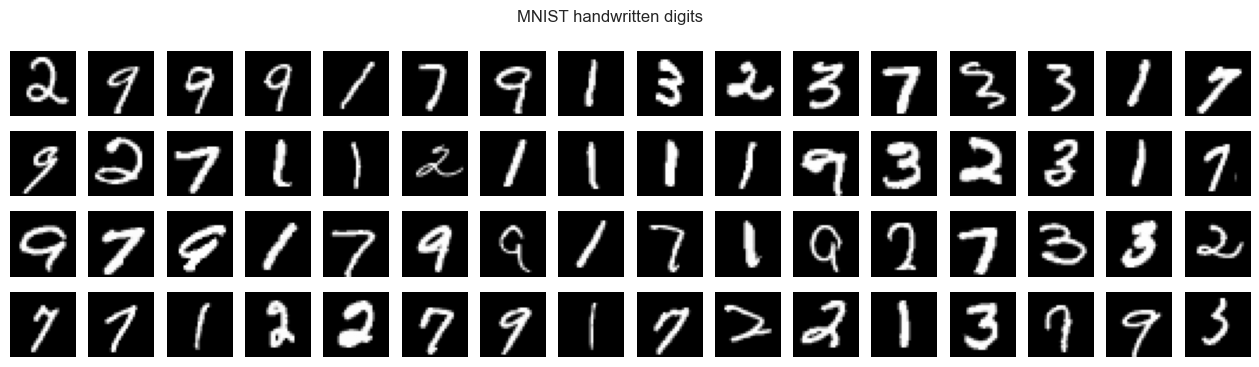

torch.Size([1, 28, 28])


In [61]:
# Plot a batch of MNIST examples
f, axarr = plt.subplots(4, 16, figsize=(16, 4))

# Load a batch of images into memory
images, labels = next(iter(train_loader))

for i, ax in enumerate(axarr.flat):
    ax.imshow(images[i].view(28, 28), cmap="binary_r")
    ax.axis('off')
    
plt.suptitle('MNIST handwritten digits')
plt.show()
print(images[1].shape)

### Building the model
When defining the model the latent layer $z$ must act as a bottleneck of information. We initialize the AE with 1 hidden layer in the encoder and decoder using ReLU units as nonlinearities. The latent layer has a dimensionality of 2 in order to make it easy to visualise. Since $x$ are pixel intensities that are normalized between 0 and 1, we use the sigmoid nonlinearity to model the reconstruction.

In [62]:
import torch.nn as nn

# Define convolutional block
def double_conv(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, 3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, 3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
    )

# define size variables
in_channels = 1
num_features = 32*7*7 # size after conv layers


class AutoEncoder(nn.Module):
    def __init__(self, hidden_units, latent_features=2):
        super(AutoEncoder, self).__init__()
        # We typically employ an "hourglass" structure
        # meaning that the decoder should be an encoder
        # in reverse.
        self.enc_conv1 = double_conv(1, 16)
        self.pool1 = nn.MaxPool2d(2) # 28x28 -> 14x14
        self.enc_conv2 = double_conv(16, 32)
        self.pool2 = nn.MaxPool2d(2) # 28x28 -> 14x14

        self.bottleneck = nn.Sequential(

            nn.Linear(in_features=num_features, out_features=hidden_units),
            nn.ReLU(),
            # bottleneck layer
            nn.Linear(in_features=hidden_units, out_features=latent_features)
        )

        self.decoder = nn.Sequential(
            nn.Linear(in_features=latent_features, out_features=hidden_units),
            nn.ReLU(),
            # output layer, projecting back to image size
            nn.Linear(in_features=hidden_units, out_features=num_features)
        )
        self.dec_upconv1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2) # upconv from 7x7 -> 14x14, bc kernel size and stride 2
        self.upconv_decoder = double_conv(16, 16)
        self.dec_upconv2 = nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2)
        
    def forward(self, x): 
        outputs = {}
        # we don't apply an activation to the bottleneck layer
        x = self.enc_conv1(x)
        x = self.pool1(x)
        x = self.enc_conv2(x)
        x = self.pool2(x)
        batch_size = x.size(0)

        x_flat = x.view(batch_size, -1)
        z = self.bottleneck(x_flat)
        
        # apply sigmoid to output to get pixel intensities between 0 and 1
        x = self.decoder(z)

        x = x.view(batch_size, 32, 7, 7)

        x = self.dec_upconv1(x)
        x = self.upconv_decoder(x)
        x = self.dec_upconv2(x)
        x_hat = torch.sigmoid(x)
        
        return {
            'z': z,
            'x_hat': x_hat
        }


# Choose the shape of the autoencoder
net = AutoEncoder(hidden_units=128, latent_features=2)

if cuda:
    net = net.cuda()

print(net)

AutoEncoder(
  (enc_conv1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc_conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, cei

Following we define the PyTorch functions for training and evaluation.

In [63]:
import torch.optim as optim

# if you want L2 regularization, then add weight_decay to SGD
optimizer = optim.SGD(net.parameters(), lr=0.25)

# We will use pixel wise mean-squared error as our loss function
loss_function = nn.MSELoss()

We can test the forward pass by checking whether the output shape is the same as the as the input.

In [64]:
# test the forward pass
# expect output size of [32, num_features]
x, y = next(iter(train_loader))
print(f"x.shape = {x.shape}")

if cuda:
    x = x.cuda()

outputs = net(x)
print(f"x_hat.shape = {outputs['x_hat'].shape}")


x.shape = torch.Size([64, 1, 28, 28])
x_hat.shape = torch.Size([64, 1, 28, 28])


In the training loop we sample each batch and evaluate the error, latent space, and reconstructions on every epoch.

**NOTE** this will take a while on CPU.

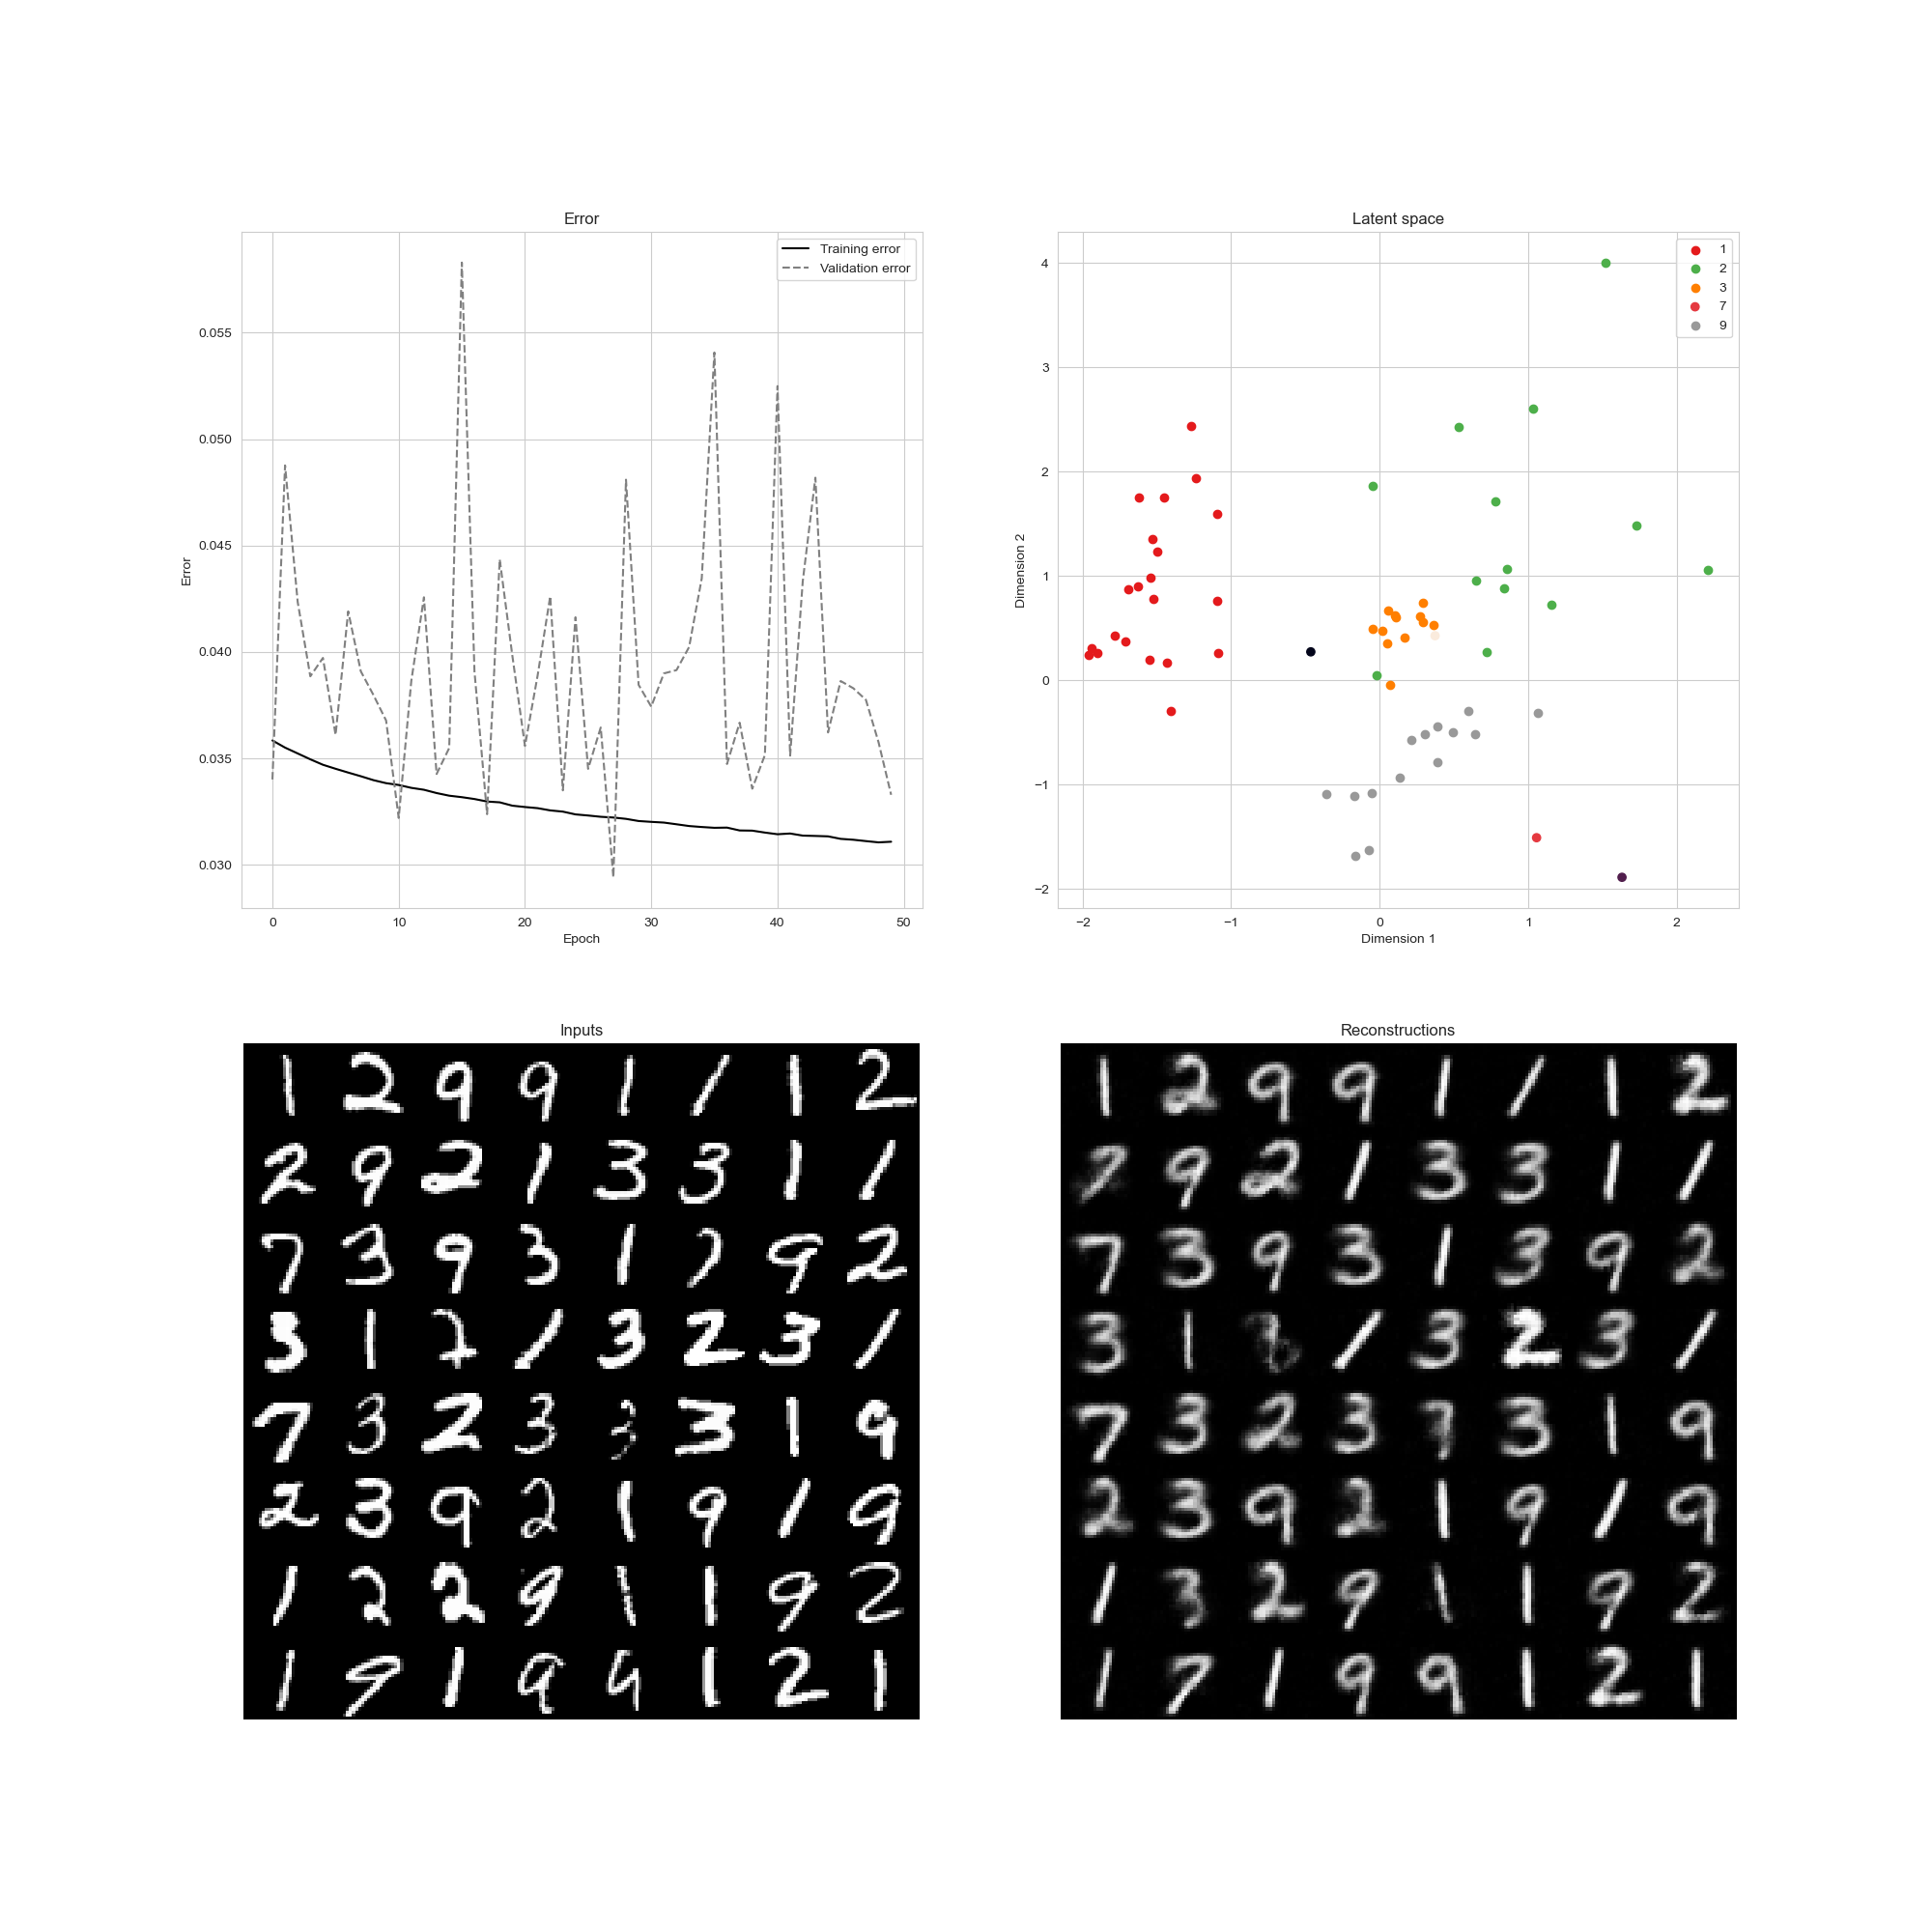

In [115]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

num_epochs = 50

train_loss = []
valid_loss = []

for epoch in range(num_epochs):
    batch_loss = []
    net.train()
    
    # Go through each batch in the training dataset using the loader
    # Note that y is not necessarily known as it is here
    for x, y in train_loader:
        
        if cuda:
            x = x.cuda()
        
        outputs = net(x)
        x_hat = outputs['x_hat']

        # note, target is the original tensor, as we're working with auto-encoders
        loss = loss_function(x_hat, x)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        batch_loss.append(loss.item())

    train_loss.append(np.mean(batch_loss))

    # Evaluate, do not propagate gradients
    with torch.no_grad():
        net.eval()
        
        # Just load a single batch from the test loader
        x, y = next(iter(test_loader))
        
        if cuda:
            x = x.cuda()
        
        outputs = net(x)

        # We save the latent variable and reconstruction for later use
        # we will need them on the CPU to plot
        x_hat = outputs['x_hat']
        z = outputs['z'].cpu().numpy()

        loss = loss_function(x_hat, x)

        valid_loss.append(loss.item())
    
    if epoch == 0:
        continue

    # live plotting of the trainig curves and representation
    plot_autoencoder_stats(x=x.cpu(),
                           x_hat=x_hat.cpu(),
                           z=z,
                           y=y,
                           train_loss=train_loss,
                           valid_loss=valid_loss,
                           epoch=epoch,
                           classes=classes,
                           dimensionality_reduction_op=None)
    
   

# Exercises

## Exercise 1: Analyzing the AE
1. The above implementation of an AE is very simple.
    - Experiment with the number of layers and try different non-linearities in order to improve the reconstructions
        - ReLU showed to be superior to tanh, and other compared with errors
    - What happens with the network when we change the non-linearities in the latent layer (e.g. sigmoid)?
        - If we use a activation function the latent layers, it would constrain the data. F.x sigmoid would constrain it in a range of 0;1 and enforces non-linearity in the latent layer. As i understand it is typically preferred to have no activation of the latent layer, since it enables the latent variable to spand from -infinity to + infinity.
    - Try to increase the number of digit classes in the training set and analyze the results
    - Test different optimization algorithms such as ADAM and RMSProp and decide whether you should use regularizers
       
2. Currently we optimize w.r.t. mean squared error. 
    - Find another error function that could fit this problem better
    - Evaluate whether the similarity function $d$ is a better choice and explain your findings

3. Complexity of the bottleneck.
    - Increase the number of units in the latent layer and train
    - Visualize by using [PCA](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) or [t-SNE](http://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)

## Exercises 2: Adding classification for semi-supervised learning

The above training has been performed unsupervised. Now let us assume that we only have a fraction of labeled data points from each class. As we know, semi-supervised learning can be utilized by combining unsupervised and supervised learning. Now you must analyze whether a trained AE from the above exercise can aid a classifier.

1. Build a simple classifier (like the ones from week1) where you:
    - Train on the labeled dataset and evaluate the results
2. Build a second classifier and train on the latent output $\mathbf{z}$ of the AE.
3. Build a third classifier and train on the reconstructions of the AE.
4. Evaluate the classifiers against each other and implement a model that improves the classification by combining the input, latent output, and reconstruction.

Below we provide some starting code for using only a subset of the labelled data.

In [66]:
def uniform_stratified_sampler(labels, classes, n=None):
    """
    Stratified sampler that distributes labels uniformly by
    sampling at most n data points per class
    """
    from functools import reduce
    # Only choose digits in n_labels
    (indices,) = np.where(reduce(lambda x, y: x | y, [labels.numpy() == i for i in classes]))

    # Ensure uniform distribution of labels
    np.random.shuffle(indices)
    indices = np.hstack([list(filter(lambda idx: labels[idx] == i, indices))[:n] for i in classes])

    indices = torch.from_numpy(indices)
    sampler = SubsetRandomSampler(indices)
    return sampler


batch_size = 64

# Specify how many labelled examples we want per digit class
labels_per_class = 10

# Large pool of unlabelled data
unlabelled = DataLoader(dset_train, batch_size=batch_size, 
                        sampler=stratified_sampler(dset_train.train_labels, classes=classes), pin_memory=cuda)

# Smaller pool of labelled data
labelled = DataLoader(dset_train, batch_size=batch_size,
                      sampler=uniform_stratified_sampler(dset_train.train_labels, classes=classes, n=labels_per_class),
                      pin_memory=cuda)

/opt/homebrew/Caskroom/miniconda/base/envs/MBML/lib/python3.10/site-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


In [117]:

num_features = 32*7*7
num_classes = 10
hidden_units = 512
class Classifier(nn.Module):
    def __init__(self):
        super(Classifier, self).__init__()

        self.enc_conv1 = double_conv(1, 16)
        self.pool1 = nn.MaxPool2d(2) # 28x28 -> 14x14

        self.enc_conv2 = double_conv(16, 32)
        self.pool2 = nn.MaxPool2d(2) # 14x14 -> 7x7

        self.clas_head = nn.Sequential(
            nn.Linear(in_features=num_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(in_features=hidden_units, out_features= num_classes)
        )

    def forward(self, x):

        x = self.enc_conv1(x)
        x = self.pool1(x)
        x = self.enc_conv2(x)
        x = self.pool2(x)

        batch_size = x.size(0)

        x_flat = x.view(batch_size, -1)

        logits = self.clas_head(x_flat)
        return logits
    
def evaluate(model, loader):
    """Evaluates the model on the given DataLoader, and prints a sample of predictions."""
    model.eval()
    correct = 0
    total = 0
    sample_printed = False
    
    with torch.no_grad():
        for images, labels in loader:
            # Check if input is 2D (latent vector) or 4D (image)
            if images.dim() == 2:
                inputs = images
            else:
                inputs = images
            
            labels = labels
            
            outputs = model(inputs)
            # Use torch.max to get the predicted class (index of the max logit)
            _, predicted = torch.max(outputs.data, 1) 
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # Print sample predictions only for the first batch
            if not sample_printed:
                N_SAMPLE = min(15, len(predicted))
                print("\n--- Sample Predictions from First Test Batch ---")
                print(f"Predicted Classes (First {N_SAMPLE}): {predicted[:N_SAMPLE].cpu().tolist()}")
                print(f"True Labels (First {N_SAMPLE}):       {labels[:N_SAMPLE].cpu().tolist()}")
                print("------------------------------------------------")
                sample_printed = True
                
    return 100 * correct / total

def train_classifier(model, train_loader, test_loader, epochs=5):
    """Training loop for the Classifier."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    print("\nStarting Classifier Training...")
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images, labels

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            
        train_accuracy = evaluate(model, train_loader)
        test_accuracy = evaluate(model, test_loader)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss / len(train_loader):.4f} | Train Acc: {train_accuracy:.2f}% | Test Acc: {test_accuracy:.2f}%")
        
    print("Classifier Training Complete.")
    


In [ ]:
from itertools import cycle

# This is an example of how you can use both the labelled
# and unlabelled loader in unison

### Define your classifier ###

# 1. Initialize the AutoEncoder (AE)
ae_net = AutoEncoder(hidden_units=10, latent_features=2)
print("--- AutoEncoder Structure ---")
print(ae_net)

# 2. Initialize the Classifier (This uses your corrected structure)
classifier_net = Classifier()
print("\n--- Classifier Structure (Your Implementation) ---")
print(classifier_net)

# 3. Train the Classifier on Labeled Data (3 epochs for a quick test)
train_classifier(classifier_net, labels, test_loader, epochs=3)

# 4. Final Evaluation using the dedicated evaluate function
final_accuracy = evaluate(classifier_net, test_loader)
print(f"\nFinal Test Accuracy: {final_accuracy:.2f}%")

--- AutoEncoder Structure ---
AutoEncoder(
  (enc_conv1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc_conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (pool2): MaxPool2d(kernel_size=2, stride

In [98]:
def train_ssl(classifier, autoencoder, labelled, unlabelled, epochs = 3, alpha = 0.5):
    """
    Semi-supervised training loop, combining the autoencoder and the classifier training. Both still separate model but with same parameter updates
    """
    optimizer = optim.Adam(list(classifier.parameters())+ list(autoencoder.parameters()), lr=0.001) # shared update rules
    
    # loss critirion
    classifier_criterion = nn.CrossEntropyLoss()
    autoencoder_criterion = nn.MSELoss()

    print(f"\nStarting Semi-Supervised Training (Alpha={alpha})...")
    for epoch in range(epochs):
        running_loss = 0

        # Train the classifier on small subset of label data, and train the autoencoder on a large dataset of unlabelled data
        for (x_lb, y_lb), (x_ul, _) in zip(cycle(labelled), unlabelled):
            autoencoder.train()
            classifier.train()
            
            optimizer.zero_grad()
            
            # pass forward labelled data and compute loss
            logits = classifier(x_lb)
            loss_class = classifier_criterion(logits, y_lb)

            # pass forward unlabelled data and compute loss
            output = autoencoder(x_ul)
            loss_au = autoencoder_criterion(output['x_hat'], x_ul)

            loss = loss_class + alpha * loss_au

            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        test_accuracy = evaluate(classifier, test_loader)
        print(f"Epoch {epoch+1}/{epochs} | Avg Loss: {running_loss / len(unlabelled):.4f} | Class Loss: {loss_class.item():.4f} | Recon Loss: {loss_au.item():.4f} | Test Acc: {test_accuracy:.2f}%")
        
    print("SSL Training Complete.")
    



In [99]:
ae_net = AutoEncoder(hidden_units= 512, latent_features=2)
print("--- AutoEncoder Structure ---")
print(ae_net)

# 2. Initialize the Classifier (This uses your corrected structure)
classifier_net = Classifier()
print("\n--- Classifier Structure (Your Implementation) ---")
print(classifier_net)

# 3. Train the Classifier using the new SSL training loop
# We train both the AE and the Classifier simultaneously using the combined loss
train_ssl(classifier_net, ae_net, labelled, unlabelled, epochs=3, alpha=0.1)

# 4. Final Evaluation using the dedicated evaluate function
final_accuracy = evaluate(classifier_net, test_loader)
print(f"\nFinal Test Accuracy of Classifier: {final_accuracy:.2f}%")

--- AutoEncoder Structure ---
AutoEncoder(
  (enc_conv1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc_conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (pool2): MaxPool2d(kernel_size=2, stride

In [100]:
class LatentClassifier(nn.Module):
    def __init__(self, latent_feature, num_classes):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(latent_feature, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes)
        )
    def forward(self, z):
        return self.classifier(z)

In [104]:
from torch.utils.data import DataLoader, SubsetRandomSampler, Dataset, TensorDataset

def generate_latent_dataset(autoencoder, labeled_loader):
    """Utility to extract Z vectors for a given dataset."""
    print("Generating Latent Dataset (Z, Y)...")
    autoencoder.eval()
    all_z = []
    all_y = []
    with torch.no_grad():
        for images, labels in labeled_loader:
            images = images
            output_dict = autoencoder(images)
            z = output_dict['z']
            all_z.append(z)
            all_y.append(labels)
            
    # Concatenate all batches and create a new TensorDataset
    latent_z = torch.cat(all_z, dim=0)
    latent_y = torch.cat(all_y, dim=0)
    
    latent_dataset = TensorDataset(latent_z, latent_y)
    
    # Create a DataLoader for the new latent dataset
    latent_loader = DataLoader(latent_dataset, batch_size=batch_size, shuffle=True)
    print(f"Latent Dataset Size: {len(latent_dataset)} samples.")
    return latent_loader
latent_train_loader = generate_latent_dataset(ae_net, labelled)
latent_test_loader = generate_latent_dataset(ae_net, test_loader)

Generating Latent Dataset (Z, Y)...
Latent Dataset Size: 50 samples.
Generating Latent Dataset (Z, Y)...
Latent Dataset Size: 5214 samples.


In [116]:
# Instantiate the latent classifier (use correct input size for latent_feature)
latent_classifier = LatentClassifier(latent_feature=2, num_classes=num_classes)
if cuda:
    latent_classifier = latent_classifier.cuda()

LATENT_EPOCHS = 200
latent_optimizer = optim.Adam(latent_classifier.parameters(), lr=0.01)
latent_criterion = nn.CrossEntropyLoss()

print(f"\nStarting Phase 2: INLINE Latent Classifier Training for {LATENT_EPOCHS} epochs...")

for epoch in range(LATENT_EPOCHS):
    running_loss = 0.0
    latent_classifier.train()
    
    for z, labels in latent_train_loader:
        z, labels = z, labels
        latent_optimizer.zero_grad()
        
        logits = latent_classifier(z)
        loss = latent_criterion(logits, labels)
        
        loss.backward()
        latent_optimizer.step()
        running_loss += loss.item()
    
    # Print status less frequently
    if (epoch + 1) % 5 == 0 or epoch == LATENT_EPOCHS - 1:
        avg_loss = running_loss / len(latent_train_loader)
        print(f"Latent Classifier Epoch {epoch+1}/{LATENT_EPOCHS} | Avg Loss: {avg_loss:.4f}")

print("Phase 2 Complete (Latent Classifier Training Finished).")



final_accuracy = evaluate(latent_classifier, latent_test_loader)

print(f"\nFinal Test Accuracy of Latent Classifier (trained on Z): {final_accuracy:.2f}%")




Starting Phase 2: INLINE Latent Classifier Training for 200 epochs...
Latent Classifier Epoch 5/200 | Avg Loss: 1.6662
Latent Classifier Epoch 10/200 | Avg Loss: 0.9482
Latent Classifier Epoch 15/200 | Avg Loss: 0.5207
Latent Classifier Epoch 20/200 | Avg Loss: 0.3601
Latent Classifier Epoch 25/200 | Avg Loss: 0.3098
Latent Classifier Epoch 30/200 | Avg Loss: 0.2803
Latent Classifier Epoch 35/200 | Avg Loss: 0.2643
Latent Classifier Epoch 40/200 | Avg Loss: 0.2568
Latent Classifier Epoch 45/200 | Avg Loss: 0.2513
Latent Classifier Epoch 50/200 | Avg Loss: 0.2467
Latent Classifier Epoch 55/200 | Avg Loss: 0.2418
Latent Classifier Epoch 60/200 | Avg Loss: 0.2376
Latent Classifier Epoch 65/200 | Avg Loss: 0.2329
Latent Classifier Epoch 70/200 | Avg Loss: 0.2287
Latent Classifier Epoch 75/200 | Avg Loss: 0.2238
Latent Classifier Epoch 80/200 | Avg Loss: 0.2185
Latent Classifier Epoch 85/200 | Avg Loss: 0.2129
Latent Classifier Epoch 90/200 | Avg Loss: 0.2069
Latent Classifier Epoch 95/200

In [118]:

final_accuracy = evaluate(latent_classifier, latent_test_loader)

print(f"\nFinal Test Accuracy of Latent Classifier (trained on Z): {final_accuracy:.2f}%")


--- Sample Predictions from First Test Batch ---
Predicted Classes (First 15): [3, 9, 2, 2, 7, 9, 2, 3, 3, 2, 1, 7, 1, 1, 9]
True Labels (First 15):       [3, 9, 2, 2, 7, 9, 2, 3, 3, 2, 1, 9, 1, 1, 7]
------------------------------------------------

Final Test Accuracy of Latent Classifier (trained on Z): 83.76%
